14:47:40 - cmdstanpy - INFO - Chain [1] start processing
14:47:40 - cmdstanpy - INFO - Chain [1] done processing



=== Performans Karşılaştırması (2025-01..07) ===
                   Model   MAE  RMSE    MAPE   sMAPE
                 Prophet 72.17 84.65 58.29 % 41.32 %
Holt-Winters (A/A, m=12) 75.74 90.91 62.23 % 42.10 %
                  SARIMA 74.41 87.91 60.40 % 41.87 %

=== Tahmin Tablosu (2025-01..07) ===
   Tarih        Gerçek    Prophet_Tahmin  HW_Tahmin   SARIMA_Tahmin
 2025-01-01      160           177           161           158     
 2025-02-01       96           157           165           160     
 2025-03-01      218           210           199           194     
 2025-04-01      219           150           160           156     
 2025-05-01      112           216           235           230     
 2025-06-01      244           355           361           356     
 2025-07-01       84           218           227           222     


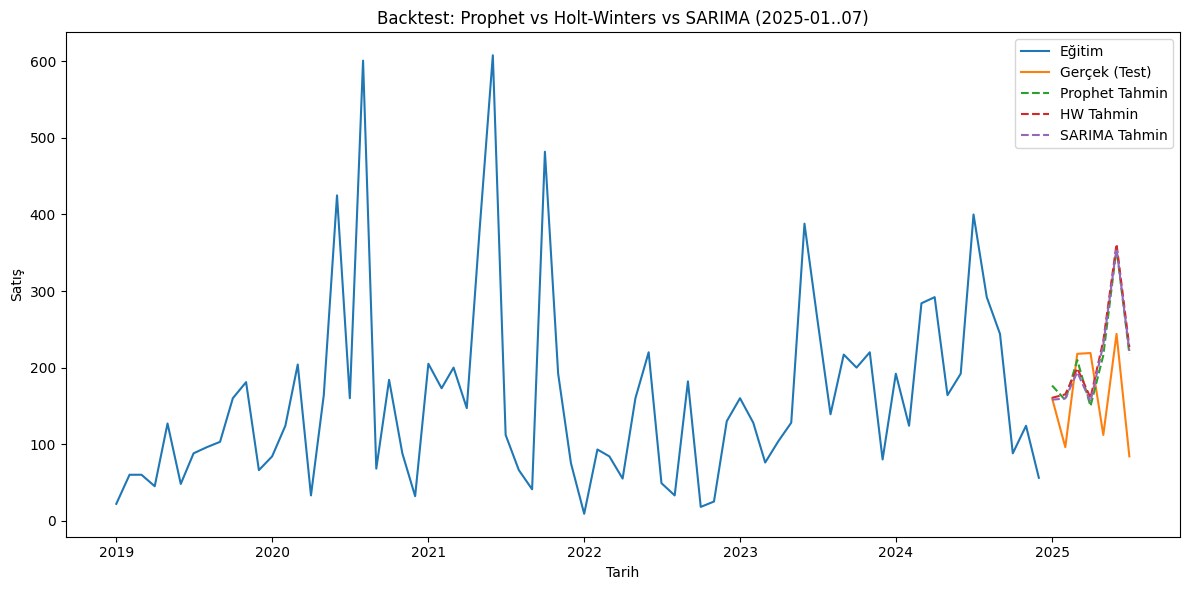

In [6]:
# ============================================
#  Sales Forecast Backtest – 3 Model Yan Yana
#  Train: 2019-01 .. 2024-12 (MS)
#  Test : 2025-01 .. 2025-07  (MS)
#  Modeller: Prophet, Holt-Winters, SARIMA
#  Stok No: '303-104092' 
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet  # pip install prophet

# ---------- 1) DATA ----------
data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}

# Aylık seri (MS = Month Start) uyumlu index
s = pd.Series(data)
s.index = pd.to_datetime(s.index)                 # bunlar ayın 1'i
idx_all = pd.date_range("2019-01-01", "2025-07-01", freq="MS")
s = s.reindex(idx_all).astype(float)

train = s.loc["2019-01-01":"2024-12-01"]         # 2019-01..2024-12
test  = s.loc["2025-01-01":"2025-07-01"]         # 2025-01..2025-07
steps = len(test)

# ---------- 2) METRICS ----------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1.0, denom)     # 0'a bölmeyi önle
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100
    sm   = smape(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "sMAPE": sm}

# ---------- 3) PROPHET ----------
# Prophet veri formatı: ds, y (ds: datetime, y: değer)
df_train = pd.DataFrame({"ds": train.index, "y": train.values})
# (Opsiyonel) outlier etkisini azaltmak isterseniz changepoint_prior_scale'i düşürebilirsiniz
prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)
prophet.fit(df_train)

# test adedi kadar MS frekansı ile ileriye tahmin
future = prophet.make_future_dataframe(periods=steps, freq="MS")
fcst   = prophet.predict(future)

# Test aralığını maskeleyelim (MS uyumlu!)
mask = (fcst["ds"] >= pd.Timestamp("2025-01-01")) & (fcst["ds"] <= pd.Timestamp("2025-07-01"))
prophet_fc = fcst.loc[mask, "yhat"].to_numpy()

# ---------- 4) HOLT-WINTERS ----------
hw = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12)
hw_fit = hw.fit(optimized=True)
hw_fc  = hw_fit.forecast(steps).to_numpy()

# ---------- 5) SARIMA ----------
# Küçük AIC araması
pdq_grid  = [(0,1,1), (1,1,1), (2,1,1)]
PDQ_grid  = [(0,1,1,12), (1,1,1,12)]
best_aic = np.inf
best_model = None
best_order = None

for order in pdq_grid:
    for sorder in PDQ_grid:
        try:
            model = SARIMAX(train, order=order, seasonal_order=sorder,
                            enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (order, sorder)
                best_model = res
        except Exception:
            pass

sarima_fc = best_model.get_forecast(steps=steps).predicted_mean.to_numpy()

# ---------- 6) METRİKLER & KARŞILAŞTIRMA ----------
y_true = test.to_numpy()

metrics = []
metrics.append(evaluate(y_true, prophet_fc, "Prophet"))
metrics.append(evaluate(y_true, hw_fc,       "Holt-Winters (A/A, m=12)"))
metrics.append(evaluate(y_true, sarima_fc,   "SARIMA"))

metrics_df = pd.DataFrame(metrics)
print("\n=== Performans Karşılaştırması (2025-01..07) ===")
print(metrics_df.to_string(index=False, formatters={
    "MAE":   lambda x: f"{x:,.2f}",
    "RMSE":  lambda x: f"{x:,.2f}",
    "MAPE":  lambda x: f"{x:,.2f} %",
    "sMAPE": lambda x: f"{x:,.2f} %"
}))

compare_df = pd.DataFrame({
    "Tarih": test.index,
    "Gerçek": y_true,
    "Prophet_Tahmin": prophet_fc,
    "HW_Tahmin": hw_fc,
    "SARIMA_Tahmin": sarima_fc
})
print("\n=== Tahmin Tablosu (2025-01..07) ===")
print(compare_df.to_string(index=False, justify="center", col_space=12, formatters={
    "Gerçek":           lambda x: f"{x:.0f}",
    "Prophet_Tahmin":   lambda x: f"{x:.0f}",
    "HW_Tahmin":        lambda x: f"{x:.0f}",
    "SARIMA_Tahmin":    lambda x: f"{x:.0f}"
}))

# ---------- 7) GRAFİK ----------
PLOT = True
if PLOT:
    plt.figure(figsize=(12,6))
    plt.plot(train.index, train.values, label="Eğitim")
    plt.plot(test.index,  test.values,  label="Gerçek (Test)")
    plt.plot(test.index,  prophet_fc,   "--", label="Prophet Tahmin")
    plt.plot(test.index,  hw_fc,        "--", label="HW Tahmin")
    plt.plot(test.index,  sarima_fc,    "--", label="SARIMA Tahmin")
    plt.title("Backtest: Prophet vs Holt-Winters vs SARIMA (2025-01..07)")
    plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
    plt.show()
